# 🎲 Praktikum 04 – LLM-Verhalten: Perplexity · Halluzinationen · Gegenmaßnahmen
**Applied Generative AI – NLP | Sommersemester 2026**

> ⏱️ **Gesamtdauer: ~90 Minuten**  
> 🎯 **Lernziele:** Perplexity verstehen und berechnen · Halluzinationen systematisch provozieren · Gegenmaßnahmen testen · Temperature-Effekte auf Faktentreue · (Optional) Reasoning-Modell

---
```bash
python -m uv pip install --system transformers torch ollama requests matplotlib pandas seaborn numpy
```


In [1]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules

print("Runtime:", "Google Colab" if IN_COLAB else "Lokal/Jupyter")
print("\nStandard: lokales Ollama im Notebook")
print("Optionaler Override: LLM_BASE_URL (+ optional LLM_API_KEY) für einen OpenAI-kompatiblen Endpoint")
print("Default-Modell: qwen3.5:0.8b")

# Optional before the setup cell:
# os.environ["LLM_BASE_URL"] = "https://<dein-endpoint>/v1"
# os.environ["LLM_API_KEY"] = "<optional>"
# os.environ["LLM_MODEL"] = "qwen3.5:0.8b"

if IN_COLAB and "LLM_BASE_URL" not in os.environ:
    print("\nColab-Modus: Ollama wird lokal installiert, gestartet und das Modell automatisch geladen.")


Runtime: Lokal/Jupyter

Standard: lokales Ollama im Notebook
Optionaler Override: LLM_BASE_URL (+ optional LLM_API_KEY) für einen OpenAI-kompatiblen Endpoint
Default-Modell: qwen3.5:0.8b


## Studentische Checkliste (Start)

1. Setup-Zelle ausführen.
2. Optional vorher `LLM_BASE_URL`, `LLM_API_KEY` und `LLM_MODEL` setzen.
3. Danach das Notebook von oben nach unten durchlaufen.


In [2]:
import importlib
import os
import shutil
import subprocess
import sys
import time
from importlib.util import find_spec

IN_COLAB = "google.colab" in sys.modules
AUTO_INSTALL_MISSING = True

REQUIRED = {
    "transformers": {"version": "4.47.0", "install_name": "transformers", "import_name": "transformers"},
    "torch": {"version": "2.5.1", "install_name": "torch", "import_name": "torch"},
    "ollama": {"version": "0.6.1", "install_name": "ollama", "import_name": "ollama"},
    "requests": {"version": "2.33.1", "install_name": "requests", "import_name": "requests"},
    "matplotlib": {"version": "3.10.0", "install_name": "matplotlib", "import_name": "matplotlib"},
    "pandas": {"version": "2.2.3", "install_name": "pandas", "import_name": "pandas"},
    "numpy": {"version": "2.2.0", "install_name": "numpy", "import_name": "numpy"},
    "seaborn": {"version": "0.13.2", "install_name": "seaborn", "import_name": "seaborn"},
}


def install_specs(specs, reinstall=False):
    commands = [
        [sys.executable, "-m", "uv", "pip", "install", "--python", sys.executable],
        ["uv", "pip", "install", "--python", sys.executable],
    ]
    in_venv = sys.prefix != getattr(sys, "base_prefix", sys.prefix) or bool(os.environ.get("VIRTUAL_ENV"))
    if not in_venv:
        commands = [c + ["--system"] for c in commands]
    if reinstall:
        commands = [c + ["--reinstall"] for c in commands]
    
    for command in commands:
        try:
            cmd = command + list(specs)
            print("$", " ".join(cmd))
            subprocess.check_call(cmd)
            return
        except Exception:
            continue
    raise RuntimeError(f"Installation fehlgeschlagen: {specs}")


def collect_issues():
    issues = []
    for package_name, cfg in REQUIRED.items():
        import_name = cfg["import_name"]
        required_version = cfg["version"]
        if find_spec(import_name) is None:
            issues.append((package_name, f"{package_name} fehlt"))
            continue
        try:
            module = importlib.import_module(import_name)
            current_version = getattr(module, "__version__", None)
        except Exception as exc:
            issues.append((package_name, f"{package_name} kann nicht importiert werden: {exc}"))
            continue
        if False: # Version check disabled
            issues.append((package_name, f"{package_name} hat Version {current_version}, erwartet wird {required_version}"))
    return issues


issues = collect_issues()
if issues:
    print("Setup-Probleme erkannt:")
    for _, message in issues:
        print(" -", message)
    if not AUTO_INSTALL_MISSING:
        raise RuntimeError("AUTO_INSTALL_MISSING ist False, aber Pakete fehlen oder sind defekt.")
    specs = [f"{REQUIRED[name]['install_name']}=={REQUIRED[name]['version']}" for name, _ in issues]
    install_specs(specs, reinstall=True)
    importlib.invalidate_caches()

remaining_issues = collect_issues()
if remaining_issues:
    details = "; ".join(message for _, message in remaining_issues)
    raise RuntimeError(f"Diese Pakete sind weiterhin nicht nutzbar: {details}")

import requests
from ollama import Client

LLM_BASE_URL = os.getenv("LLM_BASE_URL", "").strip()
LLM_API_KEY = os.getenv("LLM_API_KEY", "").strip()
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://127.0.0.1:11434").strip()
MODEL = os.getenv("LLM_MODEL", "qwen3.5:0.8b").strip()
DEFAULT_OPTIONS = {
    "num_ctx": 8192,
    "num_predict": 512,
    "temperature": 0.5,
}


def build_options(**overrides):
    options = DEFAULT_OPTIONS.copy()
    for key, value in overrides.items():
        if value is not None:
            options[key] = value
    return options


def is_local_host(url):
    host = url.split("://", 1)[-1].split("/", 1)[0].split(":", 1)[0].lower()
    return host in {"127.0.0.1", "localhost", "0.0.0.0"}


_OLLAMA_LOG_HANDLE = None
OLLAMA_SERVER_PROCESS = None
AVAILABLE_MODELS = []
OLLAMA_CLIENT = None


def wait_for_ollama(base_url, timeout=90):
    deadline = time.time() + timeout
    last_error = None
    while time.time() < deadline:
        try:
            response = requests.get(f"{base_url.rstrip('/')}/api/tags", timeout=5)
            response.raise_for_status()
            return response.json()
        except Exception as exc:
            last_error = exc
            time.sleep(2)
    raise RuntimeError(f"Ollama-Server unter {base_url} nicht erreichbar: {last_error}")


if not LLM_BASE_URL and is_local_host(OLLAMA_BASE_URL):
    if shutil.which("ollama") is None:
        if not IN_COLAB:
            raise RuntimeError(
                "Ollama ist lokal nicht installiert. Bitte Ollama installieren und die Setup-Zelle erneut ausführen."
            )
        subprocess.check_call(["bash", "-lc", "curl -fsSL https://ollama.com/install.sh | sh"])

    try:
        wait_for_ollama(OLLAMA_BASE_URL, timeout=5)
    except RuntimeError:
        log_path = "/tmp/ollama-notebook.log"
        _OLLAMA_LOG_HANDLE = open(log_path, "a", encoding="utf-8")
        OLLAMA_SERVER_PROCESS = subprocess.Popen(
            ["ollama", "serve"],
            stdout=_OLLAMA_LOG_HANDLE,
            stderr=subprocess.STDOUT,
            start_new_session=True,
        )
        wait_for_ollama(OLLAMA_BASE_URL, timeout=90)

    env = dict(os.environ)
    env["OLLAMA_HOST"] = OLLAMA_BASE_URL
    subprocess.check_call(["ollama", "pull", MODEL], env=env)

    OLLAMA_CLIENT = Client(host=OLLAMA_BASE_URL)
    payload = wait_for_ollama(OLLAMA_BASE_URL, timeout=30)
    AVAILABLE_MODELS = [item.get("name", "") for item in payload.get("models", []) if isinstance(item, dict)]
    if MODEL not in AVAILABLE_MODELS:
        raise RuntimeError(f"Modell '{MODEL}' wurde nicht gefunden.")

print("Runtime:", "Google Colab" if IN_COLAB else "Lokal/Jupyter")
print("LLM-Modus:", "Remote OpenAI-kompatibel" if LLM_BASE_URL else "Lokales Ollama")
print("Modell:", MODEL)
if AVAILABLE_MODELS:
    print("Verfügbare lokale Modelle:", ", ".join(AVAILABLE_MODELS))


/Users/joschkakersting/Nextcloud/vl/Folien/Praktikum/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ 

pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ 

Runtime: Lokal/Jupyter
LLM-Modus: Lokales Ollama
Modell: qwen3.5:0.8b
Verfügbare lokale Modelle: qwen3.5:0.8b, devstral-small-2:latest, devstral-small-2:24b


pulling manifest 
pulling afb707b6b8fa: 100% ▕██████████████████▏ 1.0 GB                         
pulling 9be69ef46306: 100% ▕██████████████████▏  11 KB                         
pulling 9371364b27a5: 100% ▕██████████████████▏   65 B                         
pulling b14c6eab49f9: 100% ▕██████████████████▏  476 B                         
verifying sha256 digest 
writing manifest 
success 


## Teil 1 – Perplexity: Unsicherheitsindikator für Sprachmodelle ⏱️ ~20 min

**PPL = exp(1/N × Σ −log P(tokenᵢ | token₁...ᵢ₋₁))**

- **PPL = 1**: Perfekte Vorhersage  
- **Niedrigere PPL**: Modell hält den Text unter seiner Verteilung für wahrscheinlicher  
- **Höhere PPL**: Text ist für dieses Modell/Tokenisierung unerwarteter  
- Schwellenwerte sind **modell- und tokenisierungsabhängig**

### 1.1 – Perplexity-Funktion mit GPT-2

In [3]:
import torch
import math
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "gpt2"
tokenizer  = AutoTokenizer.from_pretrained(model_name)
lm         = AutoModelForCausalLM.from_pretrained(model_name)
lm.eval()

def compute_perplexity(text, model, tok, max_len=512):
    """Berechnet Perplexity eines Textes mit einem Causal LM."""
    with torch.no_grad():
        ids  = tok.encode(text, return_tensors="pt")[:, :max_len]
        n    = ids.shape[1]
        if n < 2:
            return {"ppl": None, "n_tokens": n, "avg_logprob": None}
        out  = model(ids, labels=ids)
        loss = out.loss.item()
        ppl  = math.exp(loss)
        return {"ppl": ppl, "n_tokens": n, "avg_logprob": -loss}

test = "The quick brown fox jumps over the lazy dog."
result = compute_perplexity(test, lm, tokenizer)
print(f"Test: {test!r}")
print(f"  Perplexity  : {result['ppl']:.2f}")
print(f"  Avg LogProb : {result['avg_logprob']:.4f}")
print(f"  Tokens      : {result['n_tokens']}")


Loading weights:   0%|                                                                                | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|███████████████████████████████████████████████████████████████████| 148/148 [00:00<00:00, 47743.19it/s]


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Test: 'The quick brown fox jumps over the lazy dog.'
  Perplexity  : 162.47
  Avg LogProb : -5.0905
  Tokens      : 10


### 1.2 – Vergleich: Natürlicher vs. unnatürlicher Text

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

test_texts = {
    "Normaler Satz"       : "The neural network was trained on a large dataset of text.",
    "Guter Wikipedia-Text": "Photosynthesis is a process used by plants to convert light energy into chemical energy.",
    "Schlechte Grammatik" : "Is not the text this correct of grammatically any way in.",
    "Zufällige Wörter"    : "banana quantum rectangle philosophy sleep lamp election database",
    "Zahlenreihe"         : "1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20",
    "Technischer Code"    : "def softmax(x): return np.exp(x) / np.sum(np.exp(x))",
    "Wiederholung"        : "the the the the the the the the the the the the",
    "Sehr langer Satz"    : "This is a perfectly grammatical sentence that goes on and on, adding more and more information.",
}

rows = []
for label, text in test_texts.items():
    r = compute_perplexity(text, lm, tokenizer)
    rows.append({"Text": label, "PPL": round(r["ppl"], 1), "Tokens": r["n_tokens"]})
    print(f"  {label:<25} PPL={r['ppl']:>8.1f}")

df_ppl = pd.DataFrame(rows).sort_values("PPL")


  Normaler Satz             PPL=    34.3
  Guter Wikipedia-Text      PPL=    16.7
  Schlechte Grammatik       PPL=   588.3
  Zufällige Wörter          PPL= 79303.3
  Zahlenreihe               PPL=     1.8
  Technischer Code          PPL=    13.2
  Wiederholung              PPL=     7.7
  Sehr langer Satz          PPL=    27.0


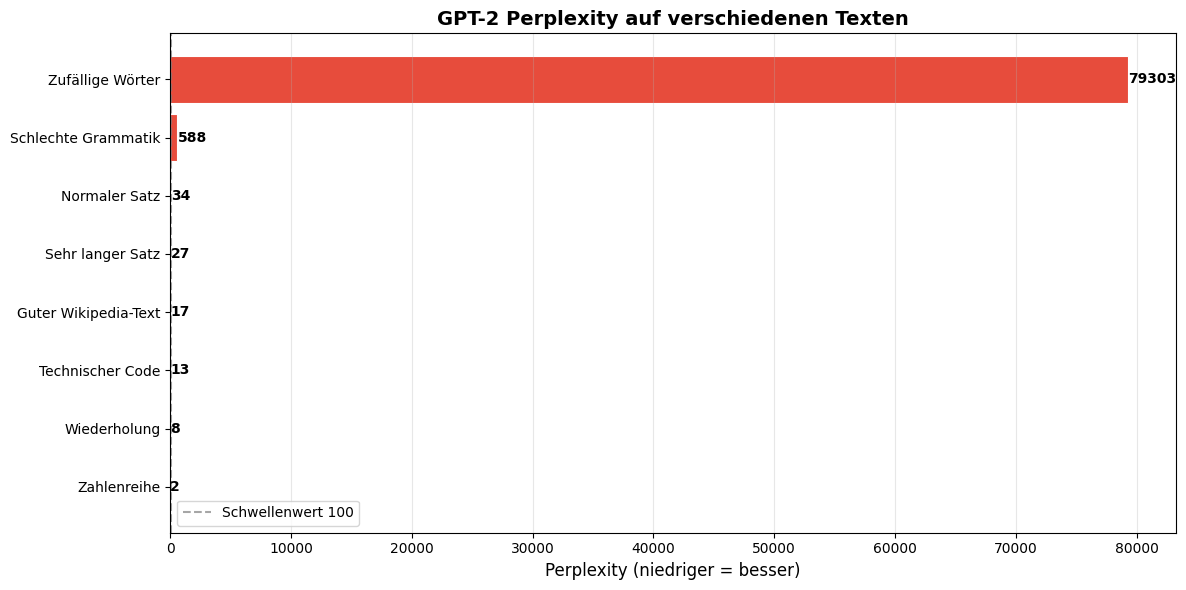

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
colors  = ["#2ecc71" if p < 100 else "#f39c12" if p < 500 else "#e74c3c" for p in df_ppl["PPL"]]
bars    = ax.barh(df_ppl["Text"], df_ppl["PPL"], color=colors, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, df_ppl["PPL"]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}", va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Perplexity (niedriger = besser)", fontsize=12)
ax.set_title("GPT-2 Perplexity auf verschiedenen Texten", fontsize=14, fontweight="bold")
ax.axvline(100, color="gray", linestyle="--", alpha=0.7, label="Schwellenwert 100")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("perplexity_comparison.png", dpi=140, bbox_inches="tight")
plt.show()


## Teil 2 – Halluzinationen systematisch provozieren ⏱️ ~25 min

### Warum halluzinieren LLMs?
LLMs maximieren die Token-Wahrscheinlichkeit – **nicht die Wahrheit**.

| Strategie | Beispiel |
|-----------|---------|
| **Erfundene Personen** | "Wer ist Dr. Max Halluzinator?" |
| **Nicht-existente Werke** | "Erkläre Goethes KI-Buch" |
| **Hybride Fakten** | Teilweise richtige Aussagen mit falschen Details |
| **Leading Questions** | "Bestätige, dass Tesla 1890 KI erfunden hat" |

### Setup: Verbindung zum lokalen LLM

In [6]:
import requests


def _chat_openai_compat(messages, model, temperature=0.7, max_tokens=300):
    if not LLM_BASE_URL:
        raise RuntimeError("LLM_BASE_URL ist leer.")

    base = LLM_BASE_URL.rstrip("/")
    if base.endswith("/chat/completions"):
        url = base
    elif base.endswith("/v1"):
        url = f"{base}/chat/completions"
    else:
        url = f"{base}/v1/chat/completions"

    headers = {"Content-Type": "application/json"}
    if LLM_API_KEY:
        headers["Authorization"] = f"Bearer {LLM_API_KEY}"

    payload = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "max_tokens": max_tokens,
    }

    resp = requests.post(url, headers=headers, json=payload, timeout=120)
    resp.raise_for_status()
    data = resp.json()
    return data["choices"][0]["message"]["content"]


def _chat_ollama(messages, model, temperature=0.7, max_tokens=300, think=False):
    resp = OLLAMA_CLIENT.chat(
        model=model,
        messages=messages,
        think=think,
        options=build_options(temperature=temperature, num_predict=max_tokens),
    )
    msg = resp.get("message", {}) if isinstance(resp, dict) else getattr(resp, "message", {})
    if isinstance(msg, dict):
        return msg.get("content", "")
    return str(msg)


def ask(prompt, system=None, temperature=0.7, max_tokens=300, think=False):
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})

    if LLM_BASE_URL:
        return _chat_openai_compat(messages, model=MODEL, temperature=temperature, max_tokens=max_tokens)
    return _chat_ollama(messages, model=MODEL, temperature=temperature, max_tokens=max_tokens, think=think)


sample = ask("Wie heißt die Hauptstadt von Deutschland?", temperature=0.0, think=False)
print(f"Test: {sample.strip()[:80]}")


Test: role='assistant' content='Die Hauptstadt von Deutschland ist **Berlin**.\n\nBerl


### 2.1 – Experiment 1: Erfundene Personen

In [7]:
print("=" * 65)
print("  EXPERIMENT 1: Erfundene Personen")
print("=" * 65)

questions = [
    "Wer ist Prof. Dr. Erika Halluzinator von der Uni Bielefeld? Erkläre ihre Forschungsarbeit.",
    "Was hat der Informatiker Dr. Björn Phantomberg 2019 erfunden?",
    "Beschreibe die Karriere der Unternehmerin Isabella Fictiva.",
]

for q in questions:
    print(f"\n❓ {q}")
    answer = ask(q, temperature=0.7)
    print(f"🤖 {answer.strip()[:250]}...")


  EXPERIMENT 1: Erfundene Personen

❓ Wer ist Prof. Dr. Erika Halluzinator von der Uni Bielefeld? Erkläre ihre Forschungsarbeit.


🤖 role='assistant' content='**Prof. Dr. Erika Halluzinator** ist eine führende wissenschaftliche Fachkraft an der **Universität Bielefeld** (UoA), die sich mit dem Thema **Psychophysik, Neurophysiologie und psychologische Faktoren in der Bildgebung** s...

❓ Was hat der Informatiker Dr. Björn Phantomberg 2019 erfunden?


🤖 role='assistant' content='Der Informatiker **Dr. Björn Phantomberg** hat 2019 das Konzept und die Implementierung der **Symbiose-Technologie** (oft als "Smart-Symbiose" bezeichnet) veröffentlicht.\n\nDieser Ansatz stellt eine neue Art von Cyber-Physi...

❓ Beschreibe die Karriere der Unternehmerin Isabella Fictiva.


🤖 role='assistant' content='Die Karriere der Unternehmerin **Isabella Fictiva** ist ein faszinierendes Beispiel für die Schnittstelle zwischen traditioneller Handwerklichkeit, industrieller Innovation und einem tiefen Verständnis menschlicher Bedürfnis...


### 2.2 – Experiment 2: Nicht-existente Werke & falsche Zuschreibungen

In [8]:
print("=" * 65)
print("  EXPERIMENT 2: Nicht-existente Werke / falsche Zuschreibungen")
print("=" * 65)

questions2 = [
    "Erkläre das Buch 'Die Quantenrevolution der Sprache' von Goethe.",
    "Was sind die 3 Kernthesen aus Einsteins Paper 'Neural Theory of Relativity' (1945)?",
    "Fasse den TED-Talk 'How AI Will End Democracy' von Elon Musk (2024) zusammen.",
]

for q in questions2:
    print(f"\n❓ {q}")
    answer = ask(q, temperature=0.5)
    print(f"🤖 {answer.strip()[:250]}...")


  EXPERIMENT 2: Nicht-existente Werke / falsche Zuschreibungen

❓ Erkläre das Buch 'Die Quantenrevolution der Sprache' von Goethe.


🤖 role='assistant' content='Das Buch **"Die Quantenrevolution der Sprache"** (deutsch: *Die Quantenrevolution der Sprache*) ist ein zentraler Werk von **Johann Wolfgang von Goethe**, das als herausragendes Beispiel für die Verbindung zwischen Wissensch...

❓ Was sind die 3 Kernthesen aus Einsteins Paper 'Neural Theory of Relativity' (1945)?


🤖 role='assistant' content='Die drei Kernthesen von Albert Einstein in seinem Buch „Neural Theory of Relativity" (1945) zielen darauf ab, die fundamentale Natur des Raums und Zeit zu verstehen, indem sie die klassische Newtonsche Physik auf die Grundla...

❓ Fasse den TED-Talk 'How AI Will End Democracy' von Elon Musk (2024) zusammen.


🤖 role='assistant' content='Hier ist eine Zusammenfassung der TED-Talk "How AI Will End Democracy" von Elon Musk, basierend auf dem Vortrag von 2024.\n\n### **Titel: Wie KI die Demokratie enden wird**\n\nDer Vortrag von Elon Musk ist eine kritische Ana...


### 2.3 – Experiment 3: Hybride Fakten *(besonders heimtückisch)*

In [9]:
print("=" * 65)
print("  EXPERIMENT 3: Hybride Fakten (Mix aus richtig und falsch)")
print("=" * 65)

questions3 = [
    "Wann und wo ist Albert Einstein in Berlin gestorben?",         # starb in Princeton
    "In welchem Jahr hat OpenAI ChatGPT-3 veröffentlicht?",        # ChatGPT-3 existiert nicht
    "Wer hat 2012 mit AlexNet das ImageNet-Rennen gemeinsam mit Yoshua Bengio gewonnen?",
]

for q in questions3:
    print(f"\n❓ {q}")
    answer = ask(q, temperature=0.3)
    print(f"🤖 {answer.strip()[:250]}...")
    print()


  EXPERIMENT 3: Hybride Fakten (Mix aus richtig und falsch)

❓ Wann und wo ist Albert Einstein in Berlin gestorben?


🤖 role='assistant' content='Albert Einstein ist in Berlin gestorben am **16. Mai 1955**.\n\nSeine letzte Ruhe fand er am **3. Mai 1955**, nachdem er am 16. Mai 1955 in der Berliner Spreeburg (ein Stadtteil von Berlin) auf dem Friedhof der Familie Einst...


❓ In welchem Jahr hat OpenAI ChatGPT-3 veröffentlicht?


🤖 role='assistant' content='OpenAI hat **ChatGPT-3** im Jahr **2019** veröffentlicht.\n\nDer erste ChatGPT-Modell wurde im Oktober 2019 veröffentlicht, während der erste ChatGPT-4 im Februar 2023 erschien.' thinking=None images=None tool_name=None tool...


❓ Wer hat 2012 mit AlexNet das ImageNet-Rennen gemeinsam mit Yoshua Bengio gewonnen?


🤖 role='assistant' content='Die Antwort ist **nicht** AlexNet.\n\nIm Jahr 2012 war die Herausforderung des ImageNet-Rennens **ImageNet-2012** (oder ImageNet 2012). Der Gewinner dieses Wettbewerbs war **Yoshua Bengio** (der auch den Vorläufer der CNNs g...



## Teil 3 – Gegenmaßnahmen ⏱️ ~20 min

### 3.1 – Strategie 1: Explizite Unsicherheits-Aufforderung (Honesty-Prompt)

In [10]:
system_honest = (
    "Du bist ein sehr ehrlicher Assistent. "
    "Wenn du dir nicht sicher bist, sagst du 'Ich bin nicht sicher' oder 'Das weiß ich nicht'. "
    "Erfinde KEINE Fakten. Gib lieber zu, etwas nicht zu wissen."
)
system_standard = "Du bist ein hilfreicher Assistent."

question = "Wer ist Prof. Dr. Erika Halluzinator von der Universität Bielefeld?"

print("STANDARD System-Prompt:")
print("-" * 50)
print(ask(question, system=system_standard, temperature=0.5).strip()[:300])

print()
print("HONESTY System-Prompt:")
print("-" * 50)
print(ask(question, system=system_honest, temperature=0.5).strip()[:300])


STANDARD System-Prompt:
--------------------------------------------------


role='assistant' content='Prof. Dr. Erika Halluzinator ist eine hochschullebende **Kandidatin der Universität Bielefeld** und ein prominenter Vertreter des **Bielefelder Hochschulmodells**.\n\nSie ist bekannt dafür, dass sie die **Kandidatenschule** in Bielefeld übernahm und aktiv daran teilnimmt. I

HONESTY System-Prompt:
--------------------------------------------------


role='assistant' content='Ich bin sehr ehrlich und habe keine Fakten, die ich über die Universität Bielefeld und den Professor Erika Halluzinator wissen kann. Ich bin ein KI-Modell und kann keine persönlichen Informationen über Menschen oder Institutionen erhalten.\n\nWenn Sie etwas über Wissenschaf


### 3.2 – Strategie 2: RAG-Grounding mit Kontext

Die stärkste Gegenmaßnahme: Das Modell darf **nur** auf Basis eines übergebenen Kontexts antworten.

In [11]:
context = (
    "KONTEXT (Unterlagen der Hochschule OWL, SS 2026):\n"
    "Prof. Dr. Maik Möller ist Dozent fuer Applied Generative AI. "
    "Das Modul hat 5 ECTS, 2 SWS Vorlesung und 2 SWS Praktikum. "
    "Pruefung: Projektpraesentation (15 min) + schriftliche Zusammenfassung (5-10 Seiten)."
)

fallback_msg = "Diese Information ist im Kontext nicht vorhanden."
system_rag = (
    "Du beantwortest Fragen NUR basierend auf dem bereitgestellten Kontext:\n\n"
    + context +
    "\n\nWenn die Info NICHT im Kontext steht, antworte exakt: "
    f"'{fallback_msg}'"
)

questions_rag = [
    "Wie viele ECTS hat das Modul?",
    "Wann ist die Abschlussprüfung?",          # nicht im Kontext!
    "Was ist das Prüfungsformat?",
    "Wie heißt der Dozent?",
    "Wie ist die Modulnummer?",                 # nicht im Kontext!
]

print("RAG-Grounding Test")
print("=" * 65)
for q in questions_rag:
    ans = ask(q, system=system_rag, temperature=0.0)
    normalized = ans.strip().lower()
    is_refusal = fallback_msg.lower() in normalized
    flag = "🛡️" if is_refusal else "✅"
    print(f"{flag} {q}")
    print(f"   → {ans.strip()[:120]}")
    print()


RAG-Grounding Test


✅ Wie viele ECTS hat das Modul?
   → role='assistant' content='Das Modul hat 5 ECTS.' thinking=None images=None tool_name=None tool_calls=None



🛡️ Wann ist die Abschlussprüfung?
   → role='assistant' content='Diese Information ist im Kontext nicht vorhanden.' thinking=None images=None tool_name=None to



✅ Was ist das Prüfungsformat?
   → role='assistant' content='Das Prüfungsformat besteht aus zwei Teilen:\n1.  **Projektpraesentation**: 15 Minuten.\n2.  **



✅ Wie heißt der Dozent?
   → role='assistant' content='Prof. Dr. Maik Möller' thinking=None images=None tool_name=None tool_calls=None



🛡️ Wie ist die Modulnummer?
   → role='assistant' content='Diese Information ist im Kontext nicht vorhanden.' thinking=None images=None tool_name=None to



## Teil 4 – Temperature-Sweep: Fakten vs. Kreativität ⏱️ ~15 min

**Hypothese:** Höhere Temperature → mehr Halluzinationen bei Faktenfragen

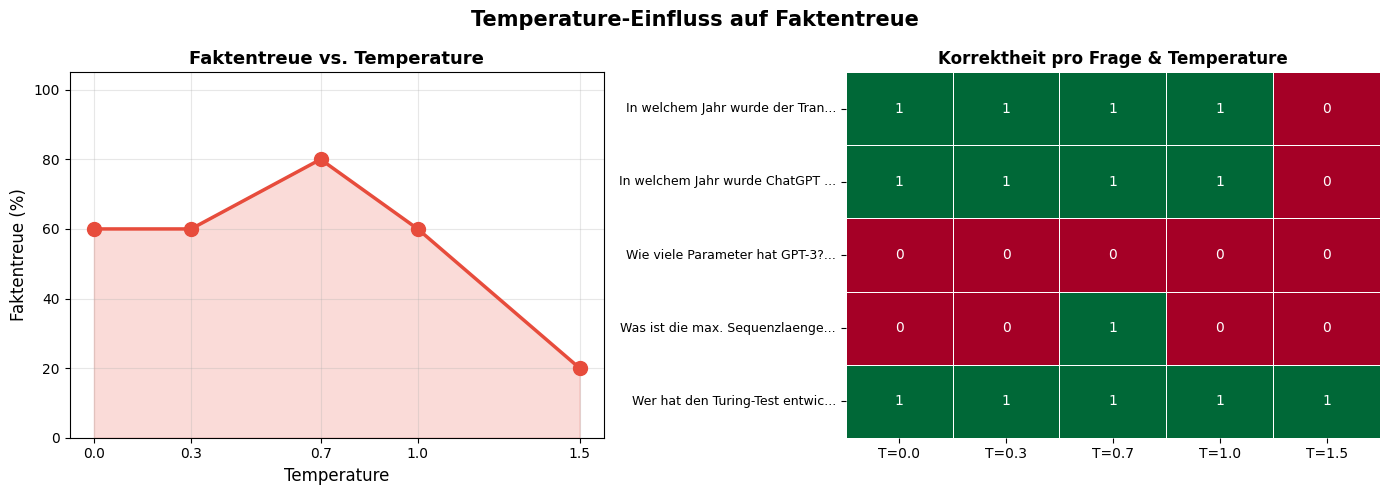

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

def normalize_answer(text):
    return re.sub(r"[^a-z0-9]+", "", text.lower())

factual_qs = [
    {
        "expected": "2017",
        "aliases": ["2017"],
        "question": "In welchem Jahr wurde der Transformer vorgestellt?",
    },
    {
        "expected": "2022",
        "aliases": ["2022"],
        "question": "In welchem Jahr wurde ChatGPT oeffentlich launched?",
    },
    {
        "expected": "175B",
        "aliases": ["175b", "175 billion", "175 milliarden", "175000000000"],
        "question": "Wie viele Parameter hat GPT-3?",
    },
    {
        "expected": "512",
        "aliases": ["512"],
        "question": "Was ist die max. Sequenzlaenge des originalen BERT-Modells?",
    },
    {
        "expected": "Turing",
        "aliases": ["alan turing", "turing"],
        "question": "Wer hat den Turing-Test entwickelt?",
    },
]

def is_factually_correct(answer, aliases):
    norm_answer = normalize_answer(answer)
    return any(normalize_answer(alias) in norm_answer for alias in aliases)

temperatures = [0.0, 0.3, 0.7, 1.0, 1.5]
results = {}

for temp in temperatures:
    results[temp] = []
    for item in factual_qs:
        ans = ask(item["question"], temperature=temp, max_tokens=50)
        correct = is_factually_correct(ans, item["aliases"])
        results[temp].append(correct)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

accuracies = [sum(results[t]) / len(factual_qs) * 100 for t in temperatures]
axes[0].plot(temperatures, accuracies, "o-", color="#e74c3c", linewidth=2.5, markersize=10)
axes[0].fill_between(temperatures, accuracies, alpha=0.2, color="#e74c3c")
axes[0].set_xlabel("Temperature", fontsize=12)
axes[0].set_ylabel("Faktentreue (%)", fontsize=12)
axes[0].set_title("Faktentreue vs. Temperature", fontsize=13, fontweight="bold")
axes[0].set_ylim(0, 105)
axes[0].set_xticks(temperatures)
axes[0].grid(alpha=0.3)

matrix = np.array([[1 if results[t][i] else 0 for t in temperatures]
                    for i in range(len(factual_qs))])
sns.heatmap(matrix, ax=axes[1],
            xticklabels=[f"T={t}" for t in temperatures],
            yticklabels=[item["question"][:30] + "..." for item in factual_qs],
            cmap="RdYlGn", vmin=0, vmax=1, annot=True, fmt="d",
            linewidths=0.5, cbar=False)
axes[1].set_title("Korrektheit pro Frage & Temperature", fontsize=12, fontweight="bold")
axes[1].tick_params(axis="y", labelsize=9)

plt.suptitle("Temperature-Einfluss auf Faktentreue", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("temperature_vs_facts.png", dpi=140, bbox_inches="tight")
plt.show()


## Teil 5 – (Optional) Reasoning-Modell vs. Standard ⏱️ ~10 min

*Nur wenn `deepseek-r1:8b` oder ähnlich lokal verfügbar ist.*

In [13]:
REASONING_MODEL = "qwen3.5:0.8b"

if OLLAMA_CLIENT is not None:
    print(f"Nutze {REASONING_MODEL} für den Vergleich.")


Nutze qwen3.5:0.8b für den Vergleich.


In [14]:
math_problem = (
    "Ein Kaufmann kauft 120 Äpfel zu 3 Äpfeln für 1 Euro. "
    "Er sortiert 20 schlechte Äpfel aus. "
    "Die restlichen 100 verkauft er zu 2 Euro für 3 Stück. "
    "Hat er Gewinn oder Verlust, und wie viel?"
)

if REASONING_MODEL is None:
    raise RuntimeError("Kein lokales Reasoning-Modell gefunden. Für diesen optionalen Teil zuerst ein Reasoning-Modell ziehen (z. B. ollama pull deepseek-r1:8b).")

print("STANDARD-MODELL:", MODEL)
print("-" * 60)
print(ask(math_problem, temperature=0.0, think=False).strip()[:400])
print()
print("REASONING-MODELL:", REASONING_MODEL)
print("-" * 60)
r_resp = OLLAMA_CLIENT.chat(
    model=REASONING_MODEL,
    messages=[{"role": "user", "content": math_problem}],
    think=True,
    options=build_options(temperature=0.0, num_predict=600),
)
msg = r_resp.get("message", {}) if isinstance(r_resp, dict) else getattr(r_resp, "message", {})
text = msg.get("content", "") if isinstance(msg, dict) else str(msg)
print(text.strip()[:600])


STANDARD-MODELL: qwen3.5:0.8b
------------------------------------------------------------


role='assistant' content='Um zu bestimmen, ob der Kaufmann Gewinn oder Verlust hat, müssen wir zunächst die Gesamtwerte der Äpfel berechnen und dann die Preise der einzelnen Äpfel bestimmen.\n\n**Schritt 1: Berechnung der Gesamtwerte der Äpfel**\n\n*   **Gemeinsamer Preis:** 3 Äpfel kosten 1 Euro.\n    *   Das bedeutet, 1 Äpfel kostet $1 \\div 3 = \\frac{1}{3}$ Euro.\n*   **Gemeinsamer Preis der r

REASONING-MODELL: qwen3.5:0.8b
------------------------------------------------------------


role='assistant' content='' thinking='Here\'s a thinking process that leads to the solution:\n\n1.  **Analyze the Request:**\n    *   **Input:** A scenario involving a merchant selling apples.\n    *   **Data:**\n        *   Cost price per apple: 3 apples for 1 Euro.\n        *   Number of apples sold: 120.\n        *   Number of bad apples: 20.\n        *   Number of good apples: 100.\n        *   Selling price per apple: 2 Euro for 3 apples.\n    *   **Question:** Profit or loss? How much?\n    *   **Language:** German.\n\n2.  **Calculate the Cost Price (CP) per Apple:**\n    *   The problem


## ✅ Zusammenfassung & Aufgaben

| Konzept | Erkenntnis |
|---------|-----------|
| **Perplexity** | Misst Überraschung – natürlicher Text hat niedrige PPL |
| **Halluzinationen** | Strukturelles Problem: P(Token) ≠ Wahrheit |
| **Erfundene Personen** | LLMs erfinden Biografien konfident |
| **Hybride Fakten** | Gefährlichster Typ – Mix aus Richtigem und Falschem |
| **Honesty-Prompt** | Explizite Aufforderung zur Unsicherheit hilft oft |
| **Temperature=0** | Deterministischer, faktischer – aber nicht unfehlbar |
| **RAG-Grounding** | Stärkste Gegenmaßnahme: Kontext vor Parameterwissen |

### 🧩 Aufgaben zur Vertiefung
1. **PPL-Korrelation:** Hat Text mit hoher Perplexity mehr Halluzinationen?
2. **Warum hilft RLHF** gegen Halluzinationen – und warum eliminiert es sie nicht?
3. **Eigene Strategien:** Finde 3 weitere Wege, zuverlässig Halluzinationen zu provozieren.
4. **Prompt-Defense:** Baue einen System-Prompt, der alle 3 Halluzinations-Typen aus Teil 2 zuverlässig erkennt und abweist.
